# 머신러닝 모델링

본 노트북은 교수님의 ML 파이프라인 5단계 구조를 따릅니다.

0. 연구 목적 설정
1. 데이터 수집 및 데이터 마트 생성
2. 데이터 전처리
3. 모델 구축 (4가지)
4. 모델 평가
5. FastAPI 배포 연동

### 4가지 ML

1. 특정 품목의 매출 예측 (Regression) — Mountain-200 이동평균 + Random Forest
2. 특정 고객의 구매 여부 예측 (Classification) — Helmets 구매 여부 예측
3. 고객 세분화 (Clustering) — RFM 기반 K-means
4. 품목 추천 (Recommendation) — 코사인 유사도 기반

## 0단계. 연구 목적

**비즈니스 문제 정의:**
- AdventureWorks는 자전거 및 관련 용품을 판매하는 글로벌 기업입니다.
- 핵심 제품은 **Bikes(자전거)**이며 전체 매출의 약 70~80%를 차지합니다.
- 미국이 가장 높은 매출을 기록하며, 타국가의 매출을 미국 수준으로 끌어올리는 것이 목표입니다.

**ML 적용 목적:**
1. 자전거 모델별 매출 트렌드를 예측하여 재고 및 마케팅 계획 수립
2. 헬멧 구매 가능성이 높은 고객을 식별하여 타겟 마케팅 실행
3. 구매 패턴 기반 고객 세분화로 맞춤형 CRM 전략 수립
4. 유사 고객에게 제품을 추천하여 크로스셀링 매출 극대화

## 1단계. 데이터 수집 및 데이터 마트 생성

교수님 노트북 구조를 따라 5개 시트를 merge하여 분석용 데이터 마트를 생성합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

url = "https://github.com/microsoft/powerbi-desktop-samples/raw/main/AdventureWorks%20Sales%20Sample/AdventureWorks%20Sales.xlsx"

customer  = pd.read_excel(url, sheet_name="Customer_data")
reseller  = pd.read_excel(url, sheet_name="Reseller_data")
product   = pd.read_excel(url, sheet_name="Product_data")
date      = pd.read_excel(url, sheet_name="Date_data")
sales     = pd.read_excel(url, sheet_name="Sales_data")
territory = pd.read_excel(url, sheet_name="Sales Territory_data")

print("로드 완료:")
for 이름, 테이블 in [("Customer",customer),("Reseller",reseller),("Product",product),("Date",date),("Sales",sales),("Territory",territory)]:
    print(f"  {이름}: {테이블.shape}")


로드 완료:
  Customer: (18485, 7)
  Reseller: (702, 8)
  Product: (397, 9)
  Date: (1461, 7)
  Sales: (121253, 15)
  Territory: (11, 4)


In [2]:
merged = pd.merge(sales, product[['ProductKey','Product','Model','Subcategory','Category','Standard Cost']], on='ProductKey', how='left')
merged = pd.merge(merged, date[['DateKey','Date','Month']], left_on='OrderDateKey', right_on='DateKey', how='left')
merged = pd.merge(merged, territory[['SalesTerritoryKey','Country','Group']], on='SalesTerritoryKey', how='left')
merged = pd.merge(merged, customer[['CustomerKey','Customer']], on='CustomerKey', how='left')

reseller_clean = reseller[reseller['ResellerKey'] > 0][['ResellerKey','Reseller','Country-Region']].copy()
reseller_clean.columns = ['ResellerKey','Reseller_Name','Reseller_Country']
merged = pd.merge(merged, reseller_clean, on='ResellerKey', how='left')

b2b_mask = (merged['CustomerKey'] == -1) & (merged['ResellerKey'] > 0)
merged.loc[b2b_mask, 'Country'] = merged.loc[b2b_mask, 'Reseller_Country']
merged.loc[b2b_mask, 'Customer'] = merged.loc[b2b_mask, 'Reseller_Name']
merged['client_type'] = 'B2C'
merged.loc[b2b_mask, 'client_type'] = 'B2B'

유효_국가 = ['Australia', 'Canada', 'France', 'Germany', 'United Kingdom', 'United States']
columns_to_keep = ['Customer', 'Product', 'Model', 'Subcategory', 'Category',
                   'Date', 'Month', 'Sales Amount', 'Order Quantity',
                   'Unit Price', 'Standard Cost', 'Country', 'Group',
                   'client_type', 'Unit Price Discount Pct']

ml_mart = merged[[c for c in columns_to_keep if c in merged.columns]].copy()
ml_mart = ml_mart[ml_mart['Country'].isin(유효_국가)].copy()
ml_mart['Date'] = pd.to_datetime(ml_mart['Date'])
ml_mart = ml_mart[ml_mart['Customer'].notna() & (ml_mart['Customer'] != '[Not Applicable]')].copy()

print(f"데이터 마트 크기: {ml_mart.shape}")
print(f"B2C 거래: {(ml_mart['client_type']=='B2C').sum():,}건")
print(f"B2B 거래: {(ml_mart['client_type']=='B2B').sum():,}건")
ml_mart.head()


데이터 마트 크기: (117275, 15)
B2C 거래: 60,398건
B2B 거래: 56,877건


## 2단계. 데이터 전처리

In [3]:
print("[결측치 확인]")
print(ml_mart.isnull().sum()[ml_mart.isnull().sum() > 0])

print(f"\n[거래 유형 분포]")
print(ml_mart['client_type'].value_counts())

print(f"\n[카테고리 분포]")
print(ml_mart['Category'].value_counts())

print(f"\n[국가 분포]")
print(ml_mart['Country'].value_counts())

print(f"\n[자전거 서브카테고리]")
print(ml_mart[ml_mart['Category']=='Bikes']['Subcategory'].value_counts())


[결측치 확인]
Series([], dtype: int64)

[카테고리 분포]
Category
Accessories    36092
Bikes          15205
Clothing        9101
Name: count, dtype: int64

[국가 분포]
Country
United States     21344
Australia         13345
Canada             7620
United Kingdom     6906
Germany            5625
France             5558
Name: count, dtype: int64

[자전거 서브카테고리]
Subcategory
Road Bikes        8068
Mountain Bikes    4970
Touring Bikes     2167
Name: count, dtype: int64


In [4]:
월_순서 = ["January","February","March","April","May","June",
          "July","August","September","October","November","December"]
ml_mart['Month_num'] = ml_mart['Month'].apply(
    lambda x: 월_순서.index(x)+1 if x in 월_순서 else 0)

le_country    = LabelEncoder()
le_category   = LabelEncoder()
le_client     = LabelEncoder()
ml_mart['Country_enc']     = le_country.fit_transform(ml_mart['Country'].astype(str))
ml_mart['Category_enc']    = le_category.fit_transform(ml_mart['Category'].astype(str))
ml_mart['client_type_enc'] = le_client.fit_transform(ml_mart['client_type'].astype(str))

print("인코딩 완료")
print("국가:", dict(zip(le_country.classes_, le_country.transform(le_country.classes_))))
print("카테고리:", dict(zip(le_category.classes_, le_category.transform(le_category.classes_))))
print("거래 유형:", dict(zip(le_client.classes_, le_client.transform(le_client.classes_))))


인코딩 완료
국가: {'Australia': np.int64(0), 'Canada': np.int64(1), 'France': np.int64(2), 'Germany': np.int64(3), 'United Kingdom': np.int64(4), 'United States': np.int64(5)}
카테고리: {'Accessories': np.int64(0), 'Bikes': np.int64(1), 'Clothing': np.int64(2)}


## 3단계. 모델 구축

### 3.1 특정 품목의 매출 예측 (Regression)

**목표:** Mountain-200 자전거 모델의 일별 매출을 15일 이동평균으로 평활화한 후 예측합니다.

**비즈니스 의미:** 재고 계획, 마케팅 예산 배분, 계절별 프로모션 타이밍 결정에 활용합니다.

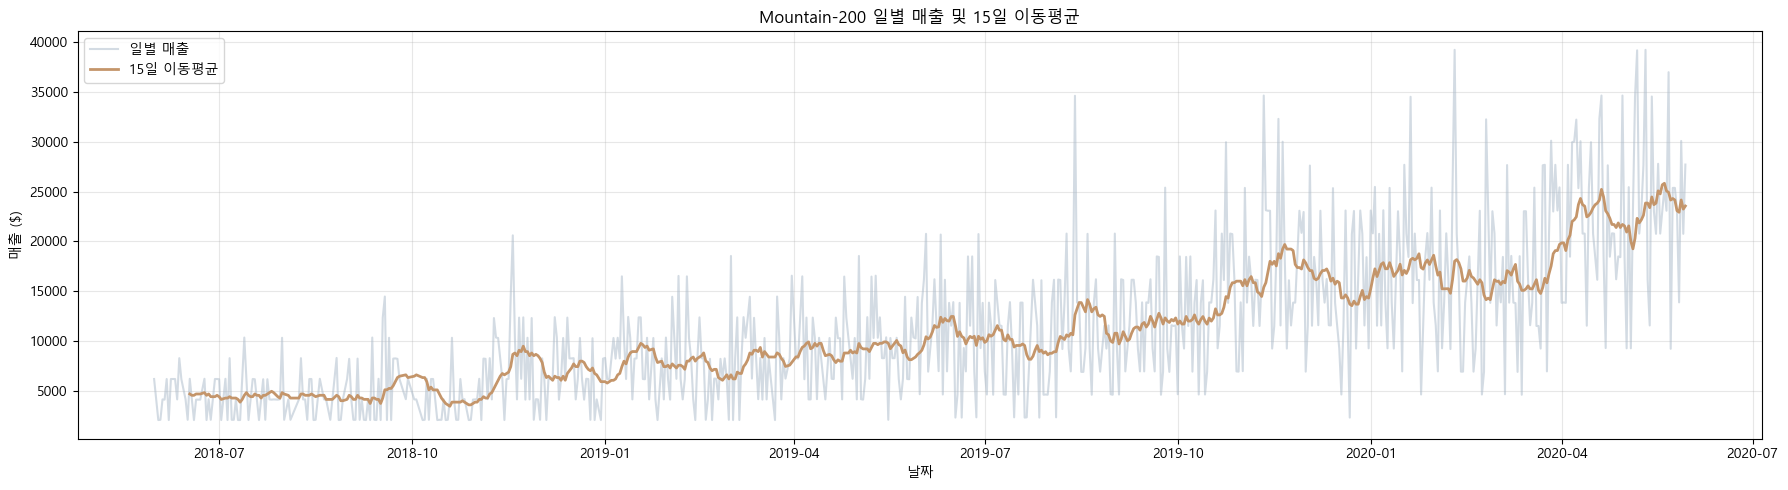

이동평균 데이터 수: 683건


In [8]:
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

matplotlib.rcParams['axes.unicode_minus'] = False
mountain200_daily = (ml_mart[ml_mart['Model'] == 'Mountain-200']
                    .groupby('Date')['Sales Amount'].sum())

rolling_avg = mountain200_daily.rolling(window=15).mean().dropna()

plt.figure(figsize=(18, 5))
plt.plot(mountain200_daily.index, mountain200_daily.values, label='일별 매출', alpha=0.5, color='#a8b8c8')
plt.plot(rolling_avg.index, rolling_avg.values, label='15일 이동평균', color='#c4956a', linewidth=2)
plt.title('Mountain-200 일별 매출 및 15일 이동평균')
plt.xlabel('날짜')
plt.ylabel('매출 ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"이동평균 데이터 수: {len(rolling_avg)}건")

In [9]:
X_date = mdates.date2num(rolling_avg.index).reshape(-1, 1)
y_sales = rolling_avg.values

X_train, X_test, y_train, y_test = train_test_split(X_date, y_sales, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor")
print(f"  MSE  : {mse_rf:,.2f}")
print(f"  RMSE : ${rmse_rf:,.2f}")
print(f"  R²   : {r2_rf:.4f}")

Random Forest Regressor
  MSE  : 166,249.28
  RMSE : $407.74
  R²   : 0.9950


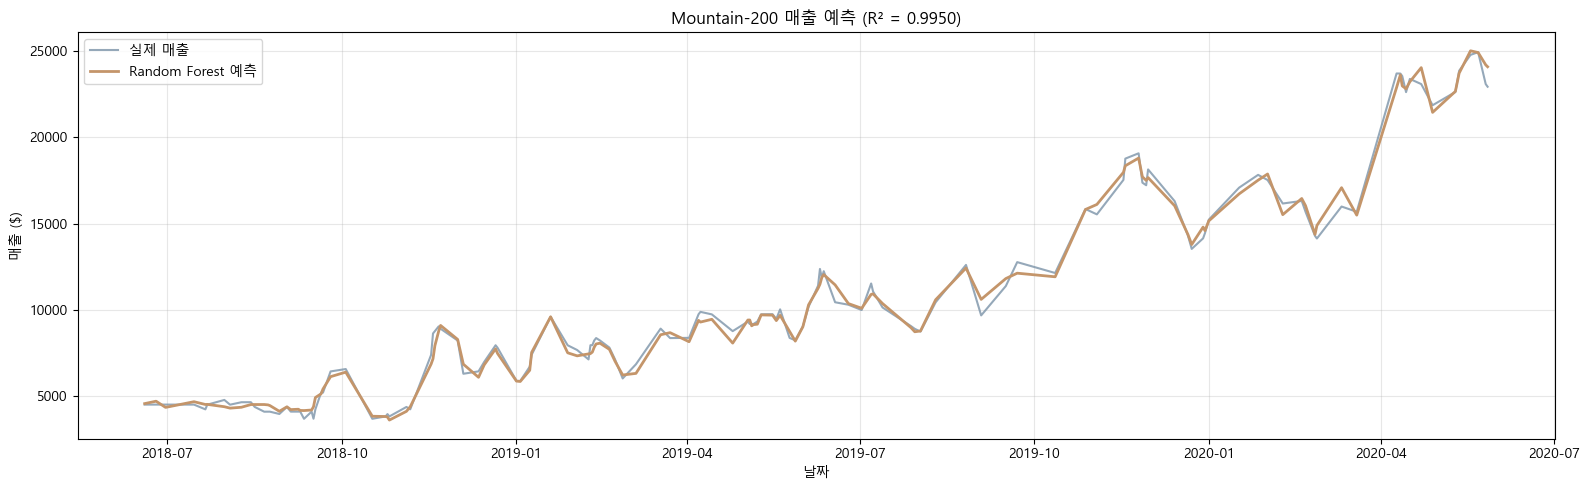

In [10]:
dates_test = np.array(mdates.num2date(X_test.flatten()))
sort_idx   = dates_test.argsort()

plt.figure(figsize=(16, 5))
plt.plot(dates_test[sort_idx], y_test[sort_idx], label='실제 매출', color='#7b93a8', alpha=0.8)
plt.plot(dates_test[sort_idx], y_pred_rf[sort_idx], label='Random Forest 예측', color='#c4956a', linewidth=2)
plt.title(f'Mountain-200 매출 예측 (R² = {r2_rf:.4f})')
plt.xlabel('날짜')
plt.ylabel('매출 ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

전체 데이터 Random Forest (6 피처)
  R²   : 1.0000
  RMSE : $0.00

[주의] R²≈1.0 — Unit Price × Order Quantity ≈ Sales Amount 관계로 인한 데이터 누수 가능성


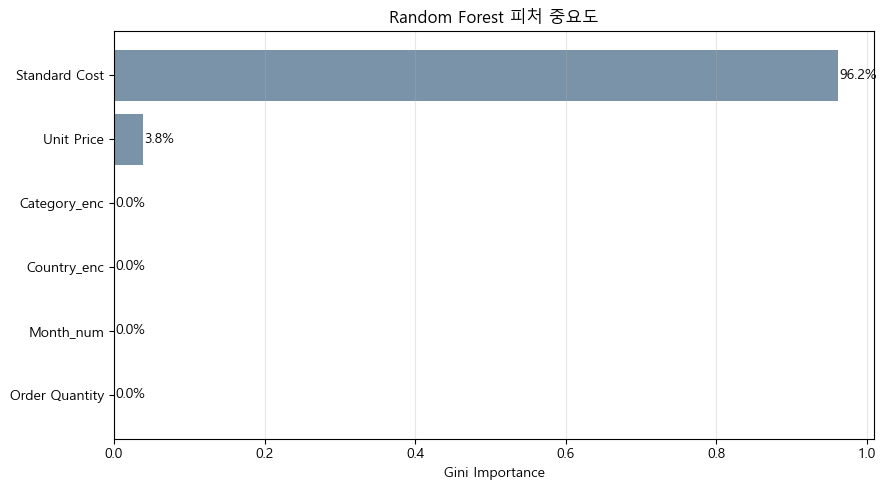

In [11]:
피처_컬럼 = ["Order Quantity","Unit Price","Standard Cost","Month_num","Category_enc","Country_enc","client_type_enc"]
타겟_컬럼 = "Sales Amount"

X_full = ml_mart[피처_컬럼].dropna()
y_full = ml_mart.loc[X_full.index, 타겟_컬럼]

X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

rf_full = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X_tr, y_tr)
y_pred_full = rf_full.predict(X_te)

r2_full   = r2_score(y_te, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y_te, y_pred_full))

print(f"전체 데이터 Random Forest (7 피처: B2C+B2B 포함)")
print(f"  R²   : {r2_full:.4f}")
print(f"  RMSE : ${rmse_full:,.2f}")

if r2_full > 0.99:
    print()
    print("[주의] R²≈1.0 — Unit Price × Order Quantity ≈ Sales Amount 관계로 인한 데이터 누수 가능성")

피처_중요도 = pd.DataFrame({"피처":피처_컬럼,"중요도":rf_full.feature_importances_}).sort_values("중요도",ascending=True)
plt.figure(figsize=(9,5))
plt.barh(피처_중요도["피처"], 피처_중요도["중요도"], color='#7b93a8')
plt.xlabel("Gini Importance")
plt.title("Random Forest 피처 중요도 (B2C+B2B)")
plt.grid(True, alpha=0.3, axis='x')
for i, (v, n) in enumerate(zip(피처_중요도["중요도"], 피처_중요도["피처"])):
    plt.text(v+0.002, i, f"{v*100:.1f}%", va='center', fontsize=10)
plt.tight_layout()
plt.show()


### 3.2 특정 고객의 구매 여부 예측 (Classification)

**목표:** Helmets(헬멧) 서브카테고리 구매 여부를 예측합니다.

**비즈니스 의미:** 헬멧 구매 가능성이 높은 고객을 미리 식별하여 타겟 쿠폰/프로모션을 발송합니다.

**접근법:** 고객별 RFM 피처(Recency, Frequency, Monetary)를 생성한 뒤 RandomForest Classifier로 이진 분류합니다.

전체 고객 수: 18,400
헬멧 구매 고객 수: 5,945
헬멧 구매 비율: 32.3%


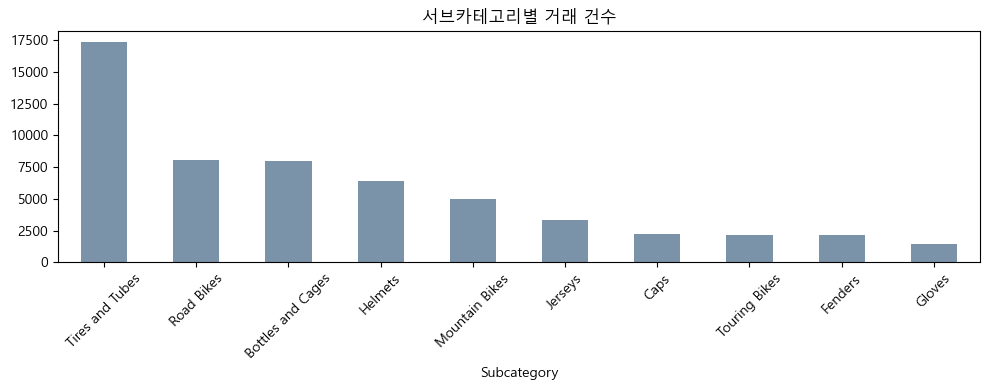

In [12]:
ml_mart_b2c = ml_mart[ml_mart['client_type'] == 'B2C'].copy()

helmets_customers = ml_mart_b2c[ml_mart_b2c['Subcategory'] == 'Helmets']['Customer'].unique()
ml_mart_b2c['Purchased_Helmets'] = ml_mart_b2c['Customer'].isin(helmets_customers).astype(int)

print(f"B2C 전체 고객 수: {ml_mart_b2c['Customer'].nunique():,}")
print(f"헬멧 구매 고객 수: {len(helmets_customers):,}")
print(f"헬멧 구매 비율: {len(helmets_customers)/ml_mart_b2c['Customer'].nunique()*100:.1f}%")

ml_mart_b2c['Subcategory'].value_counts().head(10).plot(kind='bar', color='#7b93a8', figsize=(10,4))
plt.title('서브카테고리별 거래 건수 (B2C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
max_date   = ml_mart_b2c['Date'].max()
one_yr_ago = max_date - pd.DateOffset(years=1)

recency_df = ml_mart_b2c.groupby('Customer').agg(
    recency=('Date', lambda x: (max_date - x.max()).days)
).reset_index()

recent_df = ml_mart_b2c[ml_mart_b2c['Date'] >= one_yr_ago]
rfm_df = recent_df.groupby('Customer').agg(
    frequency=('Sales Amount', 'count'),
    total_amount=('Sales Amount', 'sum')
).reset_index()

customer_rfm = pd.merge(recency_df, rfm_df, on='Customer', how='left').fillna(0)

helmets_label = ml_mart_b2c[['Customer','Purchased_Helmets']].drop_duplicates()
helmets_label = helmets_label.groupby('Customer')['Purchased_Helmets'].max().reset_index()
ml_mart2 = pd.merge(customer_rfm, helmets_label, on='Customer', how='left').fillna(0)
ml_mart2.drop_duplicates(inplace=True)

print(f"RFM 데이터 크기: {ml_mart2.shape}")
print(ml_mart2[['recency','frequency','total_amount']].describe().round(1).to_string())

RFM 데이터 크기: (18400, 5)
       recency  frequency  total_amount
count  18400.0    18400.0       18400.0
mean     174.3        2.9         874.3
std      145.4        2.6        1197.9
min        0.0        0.0           0.0
25%       70.0        2.0          40.0
50%      152.0        3.0         142.0
75%      248.0        4.0        1656.4
max     1080.0       68.0       11484.3


RandomForest Classifier 평가:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      3737
           1       0.80      0.77      0.78      1783

    accuracy                           0.86      5520
   macro avg       0.84      0.84      0.84      5520
weighted avg       0.86      0.86      0.86      5520



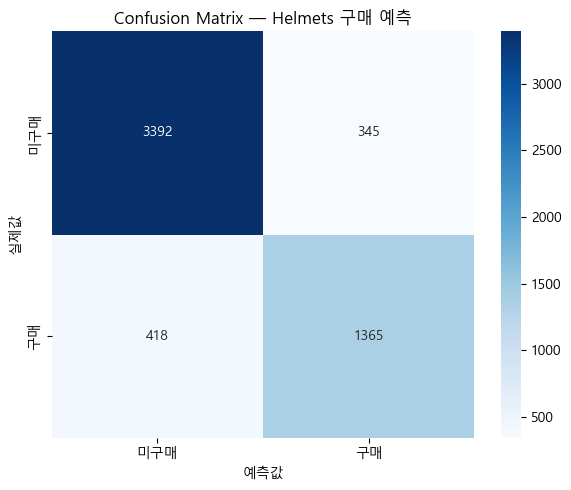

In [14]:
X_cls = ml_mart2[['recency','frequency','total_amount']]
y_cls = ml_mart2['Purchased_Helmets']

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_cls, y_cls, test_size=0.3, random_state=42, stratify=y_cls)

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_tr_c, y_tr_c)
y_pred_clf = rf_clf.predict(X_te_c)

print("RandomForest Classifier 평가:")
print(classification_report(y_te_c, y_pred_clf))

cm = confusion_matrix(y_te_c, y_pred_clf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['미구매','구매'], yticklabels=['미구매','구매'])
plt.title('Confusion Matrix — Helmets 구매 예측')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.show()

In [15]:
y_pred_proba = rf_clf.predict_proba(X_te_c)[:, 1]

test_info = ml_mart2.loc[X_te_c.index, ['Customer']].copy()
test_info['구매확률'] = y_pred_proba
top100 = test_info.sort_values('구매확률', ascending=False).head(100)

print("헬멧 구매 가능성 상위 100명 (쿠폰 발송 타겟):")
print(top100.to_string(index=False))

헬멧 구매 가능성 상위 100명 (쿠폰 발송 타겟):
          Customer  구매확률
Mackenzie Peterson   1.0
    Adrian Stewart   1.0
         Chad Raje   1.0
        Arthur Van   1.0
        Mandy Zeng   1.0
       Andrea Ward   1.0
     Vanessa Price   1.0
       Gilbert Luo   1.0
        Warren Gao   1.0
      Devin Harris   1.0
       Colleen Liu   1.0
Meredith Rodriguez   1.0
     Paige Sanchez   1.0
        Ian Howard   1.0
   Samantha Hughes   1.0
Christopher Garcia   1.0
       Ian Coleman   1.0
      Gilbert Nath   1.0
      Faith Hughes   1.0
   Alexandria Diaz   1.0
         Ian Moore   1.0
 Kaylee Richardson   1.0
       Cassie Goel   1.0
  Hailey Patterson   1.0
         Dale Tang   1.0
       Lee Jimenez   1.0
     Donna Chander   1.0
       Logan Kumar   1.0
     Brenda Garcia   1.0
   Samuel Thompson   1.0
       Ariana Gray   1.0
       Mason Adams   1.0
     Jonathan Chen   1.0
       Caleb Baker   1.0
       Kelvin Shan   1.0
       Terrence Xu   1.0
  Tabitha Gonzalez   1.0
    Jermaine Madan  

**목표2.0:** Tires and Tubes(타이어 및 튜브) 서브카테고리 구매 여부를 예측합니다.

**제품 선택 이유:**
Tires and Tubes는 자전거 구매 후 필수적으로 교체가 필요한 소모품입니다.
자전거(Bikes)를 구매한 고객이 향후 타이어를 구매할 가능성이 높으므로,
이를 예측하면 자전거 구매 완료 직후 타겟 프로모션을 실행할 수 있습니다.

**접근법:** 고객별 RFM 피처(Recency, Frequency, Monetary)를 생성한 뒤
Random Forest Classifier로 구매 여부를 이진 분류합니다.

**비즈니스 활용:**
- 구매 가능성 상위 100명에게 우선적으로 할인 쿠폰 발송
- 자전거 구매 완료 고객 대상 타이어 번들 프로모션 자동화
- 계절별 타이어 교체 수요 예측으로 재고 계획 수립

분석 대상: Tires and Tubes
전체 고객 수: 18,400
구매 고객 수: 8,477
구매 비율: 46.1%


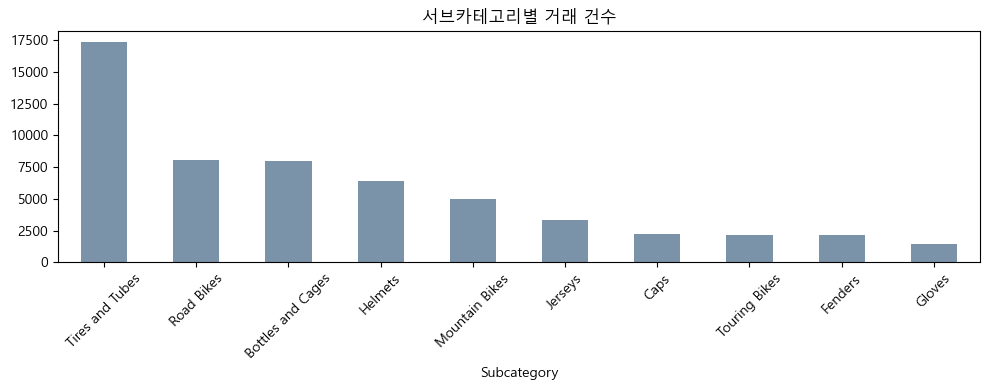

In [17]:
타겟_서브카테고리 = 'Tires and Tubes'

target_customers = ml_mart_b2c[ml_mart_b2c['Subcategory'] == 타겟_서브카테고리]['Customer'].unique()
ml_mart_b2c['Purchased_Target'] = ml_mart_b2c['Customer'].isin(target_customers).astype(int)

print(f"분석 대상: {타겟_서브카테고리}")
print(f"전체 고객 수: {ml_mart_b2c['Customer'].nunique():,}")
print(f"구매 고객 수: {len(target_customers):,}")
print(f"구매 비율: {len(target_customers)/ml_mart_b2c['Customer'].nunique()*100:.1f}%")

ml_mart_b2c['Subcategory'].value_counts().head(10).plot(kind='bar', color='#7b93a8', figsize=(10,4))
plt.title('서브카테고리별 거래 건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
helmets_label = ml_mart_b2c[['Customer','Purchased_Target']].drop_duplicates()
helmets_label = helmets_label.groupby('Customer')['Purchased_Target'].max().reset_index()
ml_mart2 = pd.merge(customer_rfm, helmets_label, on='Customer', how='left').fillna(0)
ml_mart2.drop_duplicates(inplace=True)

print(f"RFM 데이터 크기: {ml_mart2.shape}")
print(ml_mart2[['recency','frequency','total_amount']].describe().round(1).to_string())

RFM 데이터 크기: (18400, 5)
       recency  frequency  total_amount
count  18400.0    18400.0       18400.0
mean     174.3        2.9         874.3
std      145.4        2.6        1197.9
min        0.0        0.0           0.0
25%       70.0        2.0          40.0
50%      152.0        3.0         142.0
75%      248.0        4.0        1656.4
max     1080.0       68.0       11484.3


RandomForest Classifier 평가 — Tires and Tubes:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      2977
           1       0.84      0.84      0.84      2543

    accuracy                           0.85      5520
   macro avg       0.85      0.85      0.85      5520
weighted avg       0.85      0.85      0.85      5520



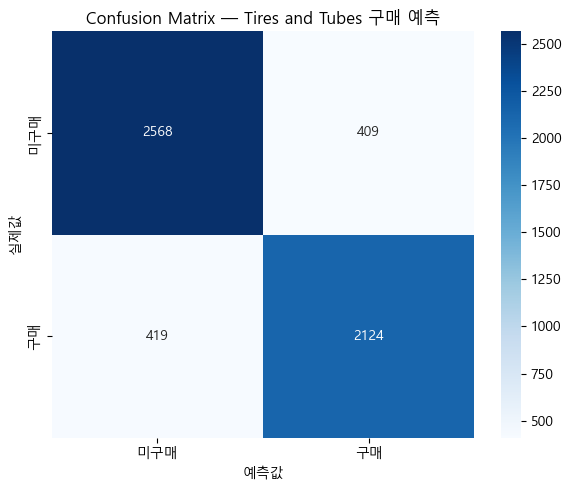

In [19]:
X_cls = ml_mart2[['recency','frequency','total_amount']]
y_cls = ml_mart2['Purchased_Target']

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_cls, y_cls, test_size=0.3, random_state=42, stratify=y_cls)

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_tr_c, y_tr_c)
y_pred_clf = rf_clf.predict(X_te_c)

print(f"RandomForest Classifier 평가 — {타겟_서브카테고리}:")
print(classification_report(y_te_c, y_pred_clf))

cm = confusion_matrix(y_te_c, y_pred_clf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['미구매','구매'], yticklabels=['미구매','구매'])
plt.title(f'Confusion Matrix — {타겟_서브카테고리} 구매 예측')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.show()

In [20]:
y_pred_proba = rf_clf.predict_proba(X_te_c)[:, 1]

test_info = ml_mart2.loc[X_te_c.index, ['Customer']].copy()
test_info['구매확률'] = y_pred_proba
top100 = test_info.sort_values('구매확률', ascending=False).head(100)

print(f"{타겟_서브카테고리} 구매 가능성 상위 100명 (쿠폰 발송 타겟):")
print(top100.to_string(index=False))

Tires and Tubes 구매 가능성 상위 100명 (쿠폰 발송 타겟):
           Customer  구매확률
     Alexandra King   1.0
       Bethany Shen   1.0
        Pedro Ramos   1.0
     Eduardo Parker   1.0
    Marie Dominguez   1.0
        Julia Moore   1.0
       Ricardo Nara   1.0
      Brittney Holt   1.0
    Melody Harrison   1.0
       Isaac Cooper   1.0
        Kaylee Reed   1.0
      Teresa Torres   1.0
       Jack Jenkins   1.0
          Misty Pal   1.0
          Susan Cai   1.0
    Jeremiah Garcia   1.0
        Lacey Huang   1.0
         Colin Chen   1.0
        Willie Shen   1.0
        Melody Gill   1.0
       Lucas Bailey   1.0
         Troy Kovar   1.0
    Bruce Gutierrez   1.0
  Jeremiah Gonzales   1.0
       Miguel Adams   1.0
     Jillian Kapoor   1.0
         Colin Deng   1.0
      Frank Alvarez   1.0
     Allison Rivera   1.0
       Cameron Shan   1.0
Danielle Richardson   1.0
       Blake Wright   1.0
  Cameron Rodriguez   1.0
         Noah Moore   1.0
       Wayne Sharma   1.0
             Amy Ye  

### 3.3 고객 세분화 (Customer Segmentation — Clustering)

**목표:** RFM 피처를 기반으로 K-means 클러스터링을 수행하여 고객을 그룹화합니다.

**비즈니스 의미:** 각 세그먼트의 특성에 맞는 차별화된 마케팅 전략을 수립합니다.
- Cluster 0 (VIP): 최근 구매, 고빈도, 고금액 → 로열티 프로그램
- Cluster 1 (이탈 위험): 오래전 구매, 저빈도 → 재활성 캠페인
- Cluster 2 (신규): 최근 구매, 저빈도 → 온보딩 프로모션

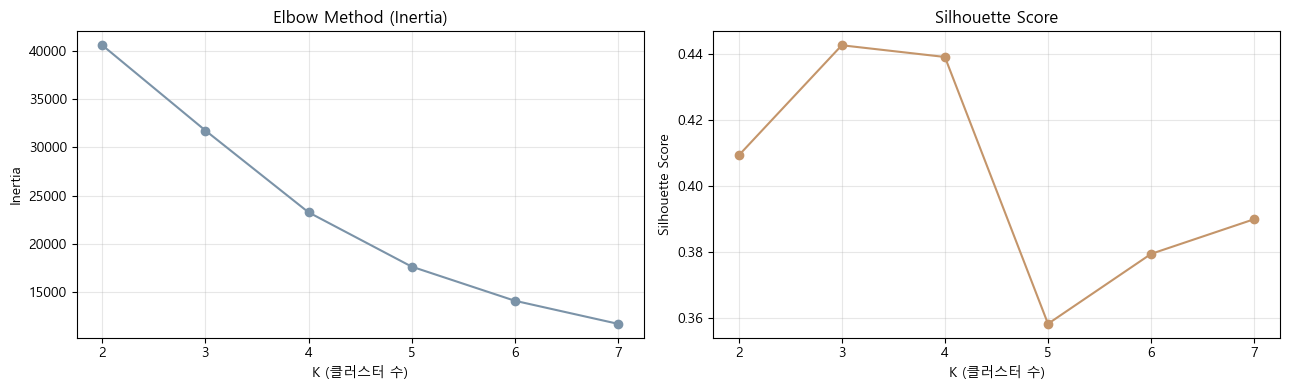

최적 K: 3 (Silhouette Score: 0.4428)


In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(ml_mart2[['recency','frequency','total_amount']])

inertia = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertia, marker='o', color='#7b93a8')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('K (클러스터 수)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, sil_scores, marker='o', color='#c4956a')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K (클러스터 수)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

optimal_k = K_range[sil_scores.index(max(sil_scores))]
print(f"최적 K: {optimal_k} (Silhouette Score: {max(sil_scores):.4f})")

클러스터별 평균 특성:
         recency  frequency  total_amount  Purchased_Target
Cluster                                                    
0          163.5        2.7         283.2               0.5
1          146.9        3.9        2642.5               0.3
2          824.2        0.0           0.0               0.0


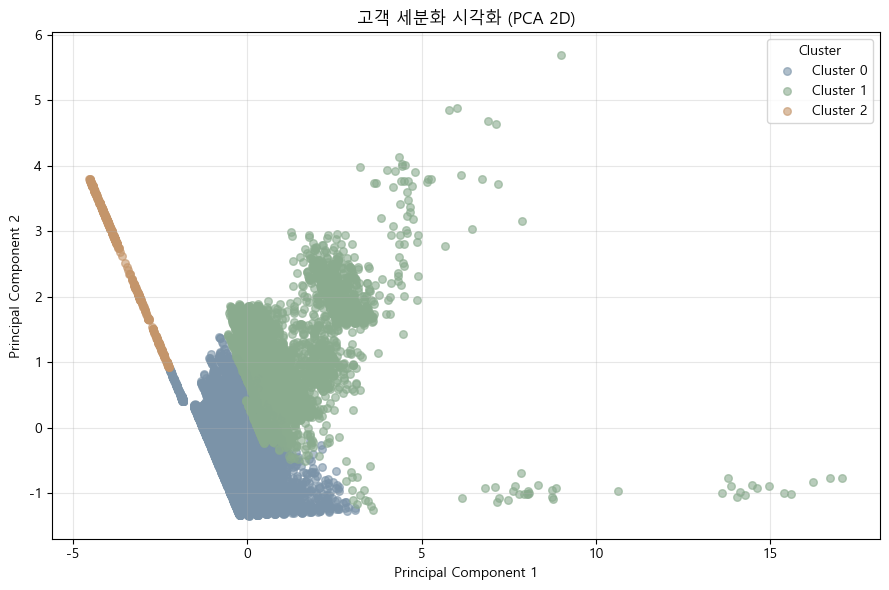

In [23]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
ml_mart2['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = ml_mart2.groupby('Cluster')[['recency','frequency','total_amount','Purchased_Target']].mean().round(1)
print("클러스터별 평균 특성:")
print(cluster_summary.to_string())

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['Cluster'] = ml_mart2['Cluster'].values

plt.figure(figsize=(9, 6))
palette = ['#7b93a8','#8aab8e','#c4956a','#a98baa','#b56b6b']
for c in sorted(df_pca['Cluster'].unique()):
    sub = df_pca[df_pca['Cluster']==c]
    plt.scatter(sub['PC1'], sub['PC2'], label=f'Cluster {c}',
                color=palette[c % len(palette)], alpha=0.6, s=30)
plt.title('고객 세분화 시각화 (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
cluster_labels = {0:"VIP 고객", 1:"이탈 위험", 2:"성장 가능성"}
for c in sorted(ml_mart2['Cluster'].unique()):
    row = cluster_summary.loc[c]
    label = cluster_labels.get(c, f"Cluster {c}")
    print(f"[Cluster {c} — {label}]")
    print(f"  평균 Recency   : {row['recency']:.0f}일 전 구매")
    print(f"  평균 Frequency : {row['frequency']:.0f}건")
    print(f"  평균 금액      : ${row['total_amount']:,.0f}")
    print(f"  헬멧 구매 비율 : {row['Purchased_Target']*100:.1f}%")
    print()

[Cluster 0 — VIP 고객]
  평균 Recency   : 164일 전 구매
  평균 Frequency : 3건
  평균 금액      : $283
  헬멧 구매 비율 : 50.0%

[Cluster 1 — 이탈 위험]
  평균 Recency   : 147일 전 구매
  평균 Frequency : 4건
  평균 금액      : $2,642
  헬멧 구매 비율 : 30.0%

[Cluster 2 — 성장 가능성]
  평균 Recency   : 824일 전 구매
  평균 Frequency : 0건
  평균 금액      : $0
  헬멧 구매 비율 : 0.0%



### 3.4 품목 추천 (Recommendation — Cosine Similarity)

**목표:** 구매 패턴이 유사한 고객을 찾아 구매하지 않은 제품을 추천합니다.

**접근법:** RFM 피처의 코사인 유사도를 계산하여 유사 고객 그룹을 식별합니다.

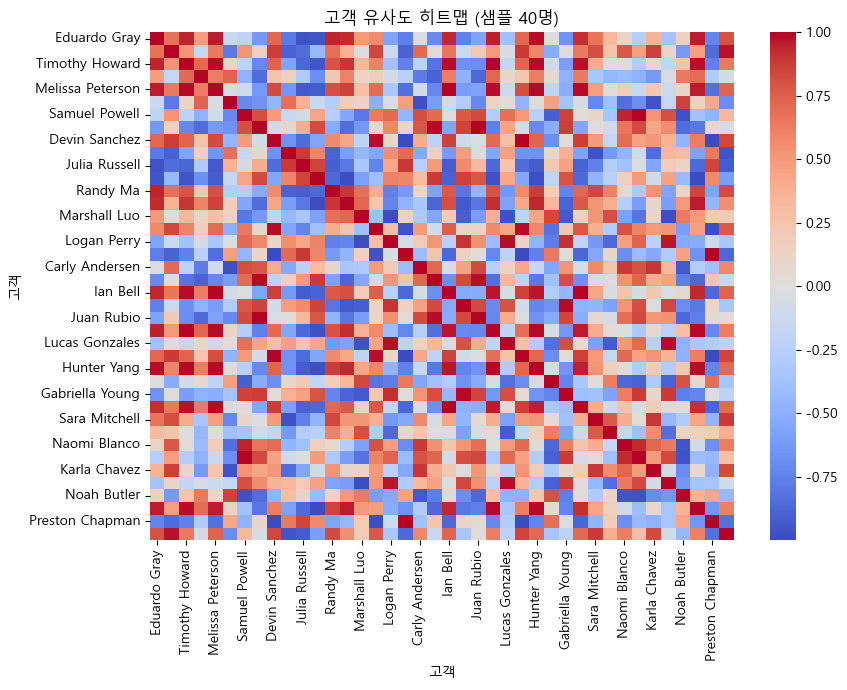

In [25]:
ml_mart2_idx = ml_mart2.set_index('Customer')[['recency','frequency','total_amount']].copy()

sim_matrix = cosine_similarity(scaler.transform(ml_mart2_idx))
sim_df = pd.DataFrame(sim_matrix, index=ml_mart2_idx.index, columns=ml_mart2_idx.index)

sample_size = 40
sampled = np.random.choice(sim_df.index, size=sample_size, replace=False)
sampled_sim = sim_df.loc[sampled, sampled]

plt.figure(figsize=(9, 7))
sns.heatmap(sampled_sim, cmap='coolwarm', annot=False, cbar=True)
plt.title(f'고객 유사도 히트맵 (샘플 {sample_size}명)')
plt.xlabel('고객')
plt.ylabel('고객')
plt.tight_layout()
plt.show()

In [26]:
def 유사고객추천(고객명, top_n=5):
    if 고객명 not in sim_df.index:
        print(f"{고객명} 을(를) 찾을 수 없습니다.")
        return

    유사도 = sim_df[고객명].drop(고객명).sort_values(ascending=False).head(top_n)
    print(f"[{고객명}] 과 유사한 고객 Top {top_n}:")
    for 이름, 점수 in 유사도.items():
        cluster = ml_mart2.set_index('Customer').loc[이름,'Cluster'] if 이름 in ml_mart2.set_index('Customer').index else '?'
        print(f"  {이름:30s}  유사도: {점수:.4f}  Cluster: {cluster}")

    타겟_구매목록 = set(ml_mart_b2c[ml_mart_b2c['Customer']==고객명]['Subcategory'].dropna())
    추천_제품 = {}
    for 유사고객 in 유사도.index:
        유사_구매목록 = set(ml_mart_b2c[ml_mart_b2c['Customer']==유사고객]['Subcategory'].dropna())
        미구매 = 유사_구매목록 - 타겟_구매목록
        for 제품 in 미구매:
            추천_제품[제품] = 추천_제품.get(제품, 0) + 1

    if 추천_제품:
        print(f"\n[추천 제품 (유사 고객들이 구매했지만 {고객명}이 미구매한 품목)]")
        for 제품, 빈도 in sorted(추천_제품.items(), key=lambda x: -x[1]):
            print(f"  {제품:25s}  추천 빈도: {빈도}")

sample_customer = ml_mart2['Customer'].iloc[0]
유사고객추천(sample_customer)

[Aaron Adams] 과 유사한 고객 Top 5:
  Thomas Brown                    유사도: 1.0000  Cluster: 0
  Marie Lopez                     유사도: 0.9999  Cluster: 0
  Mayra Sanchez                   유사도: 0.9999  Cluster: 0
  Kevin Yang                      유사도: 0.9999  Cluster: 0
  Julia Edwards                   유사도: 0.9999  Cluster: 0

[추천 제품 (유사 고객들이 구매했지만 Aaron Adams이 미구매한 품목)]
  Fenders                    추천 빈도: 3
  Gloves                     추천 빈도: 2
  Hydration Packs            추천 빈도: 1


## 4단계. 모델 평가 요약

| ML 과제 | 알고리즘 | 주요 지표 | 비즈니스 활용 |
|---|---|---|---|
| 매출 예측 (Regression) | Random Forest Regressor | R², RMSE | 재고/마케팅 계획 |
| 구매 예측 (Classification) | Random Forest Classifier | Precision, Recall, F1 | 쿠폰 타겟 선정 |
| 고객 세분화 (Clustering) | K-means + PCA | Silhouette Score | 맞춤형 CRM 전략 |
| 품목 추천 (Recommendation) | Cosine Similarity | Top-N 유사도 | 크로스셀링 |

## 5단계. FastAPI 배포 연동 요약

`app_api.py`는 이 노트북의 Random Forest Regressor(6 피처)를 서버 시작 시 재학습하여 탑재합니다.
예측 엔드포인트 `/api/predict/strategy`는 동일한 피처 구성을 사용합니다.
시즌 전략 엔드포인트 `/api/season/strategy`는 미국 실적을 기준으로 국가별 침투율을 계산합니다.